# School Bus Routing Problem (SBRP) Analysis

This notebook implements and visualizes two different algorithms for solving the School Bus Routing Problem:
1.  **Greedy Algorithm:** A heuristic that builds routes by iteratively choosing the nearest unvisited stop.
2.  **Divide and Conquer Algorithm:** A two-phase method that first clusters stops geographically and then solves the Traveling Salesman Problem (TSP) for each cluster.

We will use a predefined graph structure (adjacency list) and supplementary data (coordinates and student counts) to run the simulation. **Stop "0" is treated as the school/depot.**

## 1. Setup and Imports

First, we import the necessary libraries. `heapq` is added for the priority queue in Dijkstra's algorithm.

In [1]:
import math
import random
import re
import heapq
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import networkx as nx
from sklearn.manifold import MDS
from sklearn.preprocessing import MinMaxScaler

## 2. Data Representation and Helper Functions

Here, we define the `Stop` class, a function to calculate route cost, and a new `find_shortest_path` function that uses Dijkstra's algorithm to find the shortest path between two nodes in the graph, allowing for traversal through intermediate stops.

In [2]:
class Stop:
    """Represents a single bus stop with its properties."""
    def __init__(self, id, x, y, student_count):
        self.id = id
        self.x = x
        self.y = y
        self.coords = (x, y)
        self.student_count = student_count

    def __repr__(self):
        return f"Stop({self.id})"

def calculate_route_cost(route, cost_matrix):
    """Calculates the total distance of a single route by summing its segments."""
    total_distance = 0
    for i in range(len(route) - 1):
        loc1_id = route[i].id
        loc2_id = route[i+1].id
        total_distance += cost_matrix.get(loc1_id, {}).get(loc2_id, 0)
    return total_distance

def find_shortest_path(graph, start_id):
    """Finds the shortest path from a start node to all other nodes using Dijkstra's algorithm."""
    distances = {node: float('inf') for node in graph}
    distances[start_id] = 0
    previous_nodes = {node: None for node in graph}
    
    pq = [(0, start_id)]

    while pq:
        current_distance, current_node_id = heapq.heappop(pq)

        if current_distance > distances[current_node_id]:
            continue

        for neighbor_id, weight in graph.get(current_node_id, {}).items():
            distance = current_distance + weight
            if distance < distances[neighbor_id]:
                distances[neighbor_id] = distance
                previous_nodes[neighbor_id] = current_node_id
                heapq.heappush(pq, (distance, neighbor_id))
    
    return distances, previous_nodes

def reconstruct_path(previous_nodes, end_id):
    """Reconstructs the shortest path from the end node back to the start."""
    path = []
    current_id = end_id
    while current_id is not None:
        path.append(current_id)
        current_id = previous_nodes[current_id]
    return path[::-1] # Reverse the path to get start -> end

## 3. Algorithm Implementations

The algorithms now use the `find_shortest_path` function to navigate the graph, making them more robust for sparsely connected networks.

In [3]:
# --- Algorithm 1: Greedy Algorithm ---
def greedy_route_planner(stops, school, cost_matrix, bus_capacity, stop_map):
    """
    Constructs bus routes using a greedy 'nearest unvisited stop' strategy,
    using Dijkstra's algorithm to find the true shortest path.
    """
    unvisited_stops = list(stops)
    all_routes = []
    route_number = 1

    while unvisited_stops:
        print(f"--- Starting new route (Bus {route_number}) ---")
        print(f"Unvisited stops remaining: {len(unvisited_stops)}")
        current_route = [school]
        current_load = 0
        current_location_id = school.id
        stops_added_to_this_route = 0

        while True:
            distances, previous_nodes = find_shortest_path(cost_matrix, current_location_id)
            next_stop = None
            min_distance = float('inf')

            for stop in unvisited_stops:
                if current_load + stop.student_count <= bus_capacity:
                    distance = distances.get(stop.id, float('inf'))
                    if distance < min_distance:
                        min_distance = distance
                        next_stop = stop

            if next_stop:
                stops_added_to_this_route += 1
                path_ids = reconstruct_path(previous_nodes, next_stop.id)
                for stop_id in path_ids[1:]:
                    current_route.append(stop_map[stop_id])
                
                print(f"  Adding Stop {next_stop.id} to route via path {path_ids}. Path cost: {min_distance:.2f}. New load: {current_load + next_stop.student_count}/{bus_capacity}")
                current_load += next_stop.student_count
                current_location_id = next_stop.id
                unvisited_stops.remove(next_stop)
            else:
                print("  No more valid stops can be added to this bus (either full or no reachable stops).")
                break
        
        # *** FIX FOR INFINITE LOOP ON DISCONNECTED GRAPHS ***
        if stops_added_to_this_route == 0:
            print(f"\n[ERROR] Could not find a path to any of the remaining {len(unvisited_stops)} stops.")
            print(f"Unreachable stops: {[s.id for s in unvisited_stops]}")
            print("Stopping greedy algorithm to prevent infinite loop.")
            break

        distances, previous_nodes = find_shortest_path(cost_matrix, current_location_id)
        path_to_school = reconstruct_path(previous_nodes, school.id)
        for stop_id in path_to_school[1:]:
            current_route.append(stop_map[stop_id])
        
        all_routes.append(current_route)
        print(f"--- Finished route (Bus {route_number}). Final path: {[s.id for s in current_route]} ---")
        route_number += 1
    
    if not unvisited_stops:
        print("\nAll stops have been visited.")
    return all_routes

In [4]:
# --- Algorithm 2: Divide and Conquer (Clustering-Based) ---
def solve_tsp_for_cluster(cluster_stops, school, cost_matrix, stop_map):
    """Solves the TSP for a single cluster using a nearest-neighbor heuristic with Dijkstra's."""
    if not cluster_stops:
        return [school, school]

    tour = [school]
    current_location_id = school.id
    unvisited_in_cluster = list(cluster_stops)

    while unvisited_in_cluster:
        distances, previous_nodes = find_shortest_path(cost_matrix, current_location_id)
        next_stop = None
        min_distance = float('inf')

        for stop in unvisited_in_cluster:
            distance = distances.get(stop.id, float('inf'))
            if distance < min_distance:
                min_distance = distance
                next_stop = stop
        
        if next_stop is None:
            print(f"[Warning] Could not find path to any remaining stops in cluster from {current_location_id}")
            break

        path_ids = reconstruct_path(previous_nodes, next_stop.id)
        for stop_id in path_ids[1:]:
            tour.append(stop_map[stop_id])
        
        current_location_id = next_stop.id
        unvisited_in_cluster.remove(next_stop)
    
    distances, previous_nodes = find_shortest_path(cost_matrix, current_location_id)
    path_to_school = reconstruct_path(previous_nodes, school.id)
    for stop_id in path_to_school[1:]:
        tour.append(stop_map[stop_id])
        
    return tour

def clustering_based_planner(stops, school, num_buses, cost_matrix, stop_map):
    """Generates routes by first clustering stops and then solving TSP for each cluster."""
    stop_coords = np.array([s.coords for s in stops])
    if not stops:
        return [], None
    
    if len(stop_coords) < num_buses:
        print(f"Warning: More buses ({num_buses}) than stops ({len(stop_coords)}). Reducing number of buses.")
        num_buses = len(stop_coords)
        
    kmeans = KMeans(n_clusters=num_buses, random_state=42, n_init=10).fit(stop_coords)
    clusters = [[] for _ in range(num_buses)]
    for i, stop in enumerate(stops):
        clusters[kmeans.labels_[i]].append(stop)

    all_routes = []
    for i, cluster in enumerate(clusters):
        print(f"-- Solving TSP for Cluster {i} --")
        print("Cluster = ", cluster)
        route = solve_tsp_for_cluster(cluster, school, cost_matrix, stop_map)
        print("Route = ", route)
        all_routes.append(route)
        
    return all_routes, kmeans.labels_

## 4. Visualization Function

This function plots the results, showing the school, stop locations, and the generated bus routes. It can color-code stops by cluster for the Divide and Conquer algorithm.

In [5]:
def visualize_routes(stops, school, routes, algorithm_name, cluster_labels=None):
    """
    Plots the school, bus stops, and the generated routes.
    """
    plt.figure(figsize=(14, 12))
    
    # Plot school
    plt.scatter(school.coords[0], school.coords[1], c='red', marker='s', s=200, label=f'School (Stop {school.id})', zorder=5)
    
    # Plot stops (excluding the school)
    pickup_stops = [s for s in stops if s.id != school.id]
    if pickup_stops:
        if cluster_labels is not None:
            # Adjust cluster labels to match the pickup_stops list
            stop_id_to_label = {stop.id: label for stop, label in zip(stops, cluster_labels)}
            ordered_labels = [stop_id_to_label[s.id] for s in pickup_stops]
            unique_labels = sorted(list(set(ordered_labels)))
            scatter = plt.scatter([s.x for s in pickup_stops], [s.y for s in pickup_stops], c=ordered_labels, cmap='viridis', s=60, zorder=4)
            plt.legend(handles=scatter.legend_elements()[0], labels=[f'Cluster {i}' for i in unique_labels], title="Clusters")
        else:
            plt.scatter([s.x for s in pickup_stops], [s.y for s in pickup_stops], c='blue', s=60, label='Stops', zorder=4)

    # Plot routes
    colors = plt.cm.rainbow(np.linspace(0, 1, len(routes)))
    for i, route in enumerate(routes):
        if len(route) > 1:
            route_coords = [loc.coords for loc in route]
            x_coords, y_coords = zip(*route_coords)
            plt.plot(x_coords, y_coords, color=colors[i], marker='o', markersize=5, linestyle='-')

    plt.title(f'School Bus Routes from {algorithm_name}', fontsize=16)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    # Re-add school to legend to ensure it appears
    handles, labels = plt.gca().get_legend_handles_labels()
    school_handle = plt.Line2D([0], [0], marker='s', color='w', label=f'School (Stop {school.id})', markersize=10, markerfacecolor='red')
    handles.append(school_handle)
    plt.legend(handles=handles)
    plt.show()

## 5. Data Loading and Simulation

Here we define the simulation parameters and load the data. A `stop_map` is created for quick lookups, and the capacity check is performed before running the updated algorithms.

In [6]:
# Simulation Settings
NUM_BUSES = 3
BUS_CAPACITY = 30
AREA_WIDTH = 100
AREA_HEIGHT = 100

# 1. Load Provided Graph Data
adj_list = {
    '0': [['1', 2], ['6', 2], ['18', 2], ['25', 2], ['26', 2]],
    '1': [['2', 4],['6',1],['7',2]],
    '2': [['1', 4]],
    '3': [['4', 1], ['12', 1]],
    '4': [['3', 1], ['9', 1]],
    '5': [['6', 1], ['9', 1]],
    '6': [['0', 2], ['1', 1],['5',1],['26',1]],
    '7': [['1', 2], ['8', 1]],
    '8': [['7', 1]],
    '9': [['4', 1], ['5', 1],['10',1]],
    '10': [['9', 1], ['11', 1]],
    '11': [['10', 1], ['12', 1]],
    '12': [['11', 1], ['3', 1]],
    '13': [['14', 2]],
    '14': [['13', 2],['19',2]],
    '15': [['16', 1], ['18', 1]],
    '16': [['15', 1], ['17', 1]],
    '17': [['16', 1], ['18', 1]],
    '18': [['0',2],['19', 1]],
    '19': [['14', 2], ['18', 1], ['20', 1]],
    '20': [['19',1],['21',1]],
    '21':[['20',1]],
    '24':[['0',1],['18',1],['25',1]],
    '25':[['0',2],['24',2]],
    '26':[['0',2],['27',1],['34',1]],
    '27':[['26',1],['28',1]],
    '28':[['27',1]],
    '34':[['26',1]]
}

In [7]:
# 2. Create Stop Objects and Full Cost Matrix via MDS

# --- STEP A: Build a NetworkX graph to calculate real distances ---
G = nx.Graph()
all_stop_ids = set(adj_list.keys())

# Build the graph from the adjacency list
for stop_id, neighbors in adj_list.items():
    all_stop_ids.add(str(stop_id))
    for neighbor in neighbors:
        # Assuming neighbor structure is (neighbor_id, weight)
        # If your adj_list just has IDs, remove [1] and set weight=1
        nbr_id = str(neighbor[0])
        weight = neighbor[1] if len(neighbor) > 1 else 1 
        G.add_edge(str(stop_id), nbr_id, weight=weight)
        all_stop_ids.add(nbr_id)

# Ensure we have a sorted list of IDs so indices match the matrix
sorted_stop_ids = sorted(list(all_stop_ids))
id_to_index = {stop_id: i for i, stop_id in enumerate(sorted_stop_ids)}
n_samples = len(sorted_stop_ids)

# --- STEP B: Generate the All-Pairs Shortest Path Matrix ---
# Initialize matrix with infinity
cost_matrix = np.full((n_samples, n_samples), np.inf)
np.fill_diagonal(cost_matrix, 0)

# Compute shortest paths (Dijkstra/Floyd-Warshall)
# dict(nx.all_pairs_dijkstra_path_length(G)) is efficient for sparse graphs
path_lengths = dict(nx.all_pairs_dijkstra_path_length(G))

for i, id_i in enumerate(sorted_stop_ids):
    for j, id_j in enumerate(sorted_stop_ids):
        if id_j in path_lengths.get(id_i, {}):
            cost_matrix[i][j] = path_lengths[id_i][id_j]
        else:
             # Handle disconnected components if necessary
             # Set to a large number so MDS pushes them apart
            cost_matrix[i][j] = np.max(cost_matrix[cost_matrix != np.inf]) * 2

# --- STEP C: Apply MDS to project to 2D ---
# dissimilarity='precomputed' tells MDS we are giving it a distance matrix, not raw data points
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
pos_2d = mds.fit_transform(cost_matrix)

# --- STEP D: Scale coordinates to fit your Area Size ---
# MDS output is centered at 0. We scale it to [0, AREA_WIDTH]
scaler = MinMaxScaler(feature_range=(0, 1))
pos_2d_scaled = scaler.fit_transform(pos_2d)

stop_coordinates = {}
for i, stop_id in enumerate(sorted_stop_ids):
    x = pos_2d_scaled[i][0] * AREA_WIDTH
    y = pos_2d_scaled[i][1] * AREA_HEIGHT
    stop_coordinates[stop_id] = (x, y)

# --- STEP E: Create Objects ---
school_id = '0'
# Ensure school is in the map; if not, default to center or existing coord
school_coords = stop_coordinates.get(school_id, (AREA_WIDTH/2, AREA_HEIGHT/2))
school = Stop(school_id, school_coords[0], school_coords[1], 0)

stops = []
for stop_id in all_stop_ids:
    if stop_id != school_id:
        coords = stop_coordinates[stop_id]
        stops.append(Stop(stop_id, coords[0], coords[1], random.randint(1, 5)))

stop_map = {s.id: s for s in stops}
stop_map[school.id] = school

# --- CHECK AND GUARANTEE BUS CAPACITY ---
total_students = sum(s.student_count for s in stops)
total_capacity = NUM_BUSES * BUS_CAPACITY
print(f"Total students to pick up: {total_students}")
print(f"Initial total bus capacity: {total_capacity} ({NUM_BUSES} buses * {BUS_CAPACITY} capacity)")
if total_students > total_capacity:
    required_buses = math.ceil(total_students / BUS_CAPACITY)
    print(f"\nWarning: Not enough capacity. Required buses: {required_buses}. Adjusting NUM_BUSES from {NUM_BUSES} to {required_buses}.")
    NUM_BUSES = required_buses
    print(f"New total bus capacity: {NUM_BUSES * BUS_CAPACITY}\n")
else:
    print("Sufficient bus capacity available.\n")

# Build the cost matrix directly from the adjacency list
cost_matrix = {stop_id: {} for stop_id in all_stop_ids}
for stop_id, neighbors in adj_list.items():
    for neighbor in neighbors:
        if len(neighbor) == 2:
            neighbor_id, distance = str(neighbor[0]), neighbor[1]
            cost_matrix[stop_id][neighbor_id] = distance
            if neighbor_id not in cost_matrix: cost_matrix[neighbor_id] = {}
            cost_matrix[neighbor_id][stop_id] = distance

Total students to pick up: 88
Initial total bus capacity: 90 (3 buses * 30 capacity)
Sufficient bus capacity available.



In [8]:
# 3. Run Greedy Algorithm
print("--- Running Greedy Algorithm ---")
greedy_routes = greedy_route_planner(stops, school, cost_matrix, BUS_CAPACITY, stop_map)
total_greedy_cost = sum(calculate_route_cost(r, cost_matrix) for r in greedy_routes)
print(f"Generated {len(greedy_routes)} routes.")
print(f"Total distance: {total_greedy_cost:.2f}\n")

--- Running Greedy Algorithm ---
--- Starting new route (Bus 1) ---
Unvisited stops remaining: 27
  Adding Stop 24 to route via path ['0', '24']. Path cost: 1.00. New load: 2/30
  Adding Stop 18 to route via path ['24', '18']. Path cost: 1.00. New load: 6/30
  Adding Stop 19 to route via path ['18', '19']. Path cost: 1.00. New load: 11/30
  Adding Stop 20 to route via path ['19', '20']. Path cost: 1.00. New load: 14/30
  Adding Stop 21 to route via path ['20', '21']. Path cost: 1.00. New load: 16/30
  Adding Stop 14 to route via path ['21', '20', '19', '14']. Path cost: 4.00. New load: 18/30
  Adding Stop 13 to route via path ['14', '13']. Path cost: 2.00. New load: 20/30
  Adding Stop 15 to route via path ['13', '14', '19', '18', '15']. Path cost: 6.00. New load: 23/30
  Adding Stop 16 to route via path ['15', '16']. Path cost: 1.00. New load: 26/30
  Adding Stop 17 to route via path ['16', '17']. Path cost: 1.00. New load: 30/30
  No more valid stops can be added to this bus (either 

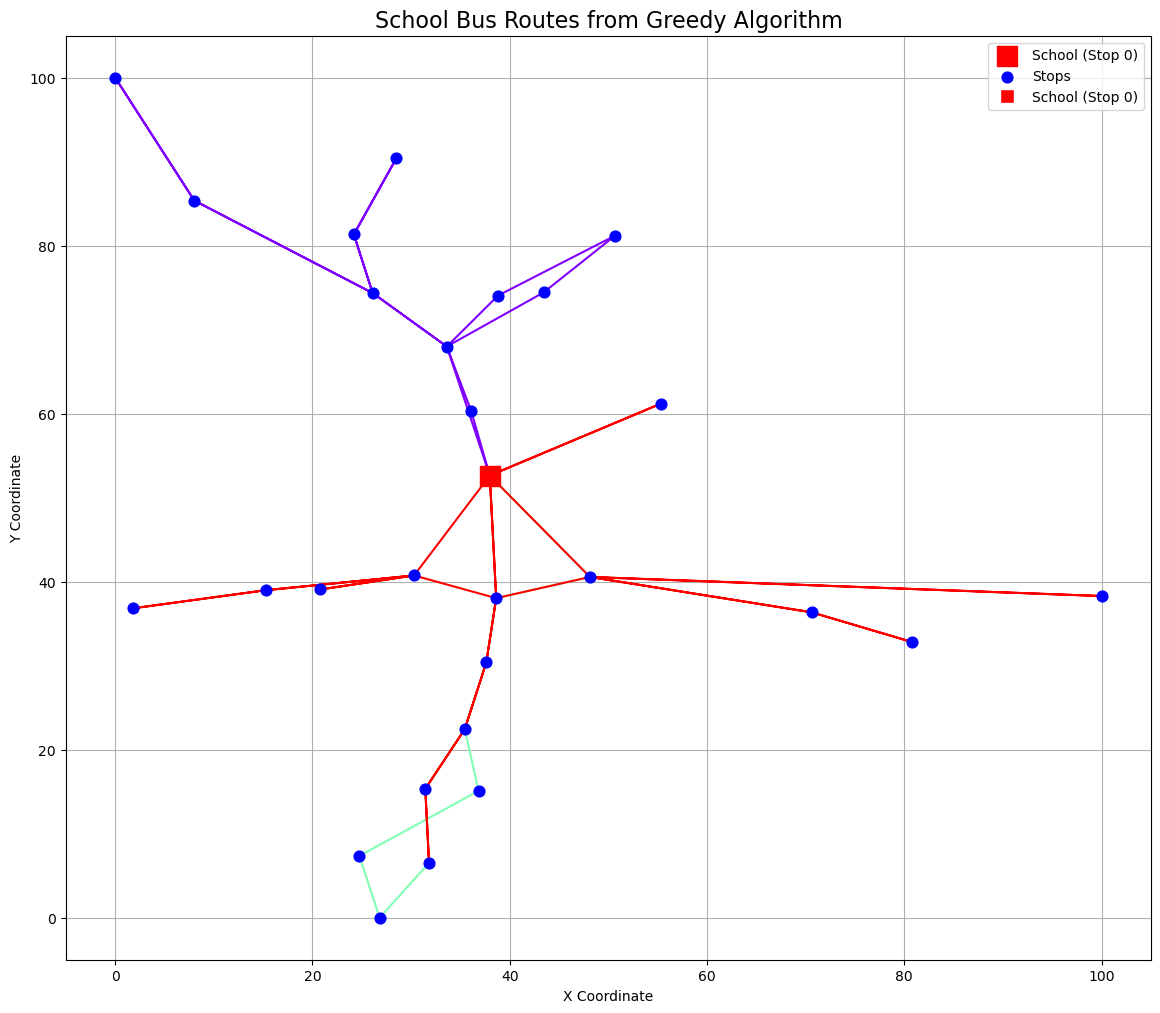

In [9]:
# Visualize Greedy Algorithms
visualize_routes(stops, school, greedy_routes, "Greedy Algorithm")


In [10]:
# 4. Run Clustering Algorithm
print("--- Running Clustering-Based Algorithm ---")
clustering_routes, labels = clustering_based_planner(stops, school, NUM_BUSES, cost_matrix, stop_map)
total_clustering_cost = sum(calculate_route_cost(r, cost_matrix) for r in clustering_routes)
print(f"Generated {len(clustering_routes)} routes.")
print(f"Total distance: {total_clustering_cost:.2f}\n")

--- Running Clustering-Based Algorithm ---
-- Solving TSP for Cluster 0 --
Cluster =  [Stop(20), Stop(14), Stop(19), Stop(24), Stop(18), Stop(15), Stop(21), Stop(16), Stop(17), Stop(25), Stop(13)]
Route =  [Stop(0), Stop(24), Stop(18), Stop(19), Stop(20), Stop(21), Stop(20), Stop(19), Stop(14), Stop(13), Stop(14), Stop(19), Stop(18), Stop(15), Stop(16), Stop(17), Stop(18), Stop(24), Stop(25), Stop(0)]
-- Solving TSP for Cluster 1 --
Cluster =  [Stop(34), Stop(28), Stop(12), Stop(4), Stop(5), Stop(1), Stop(9), Stop(26), Stop(27), Stop(3), Stop(10), Stop(11), Stop(6)]
Route =  [Stop(0), Stop(1), Stop(6), Stop(5), Stop(9), Stop(4), Stop(3), Stop(12), Stop(11), Stop(10), Stop(9), Stop(5), Stop(6), Stop(26), Stop(34), Stop(26), Stop(27), Stop(28), Stop(27), Stop(26), Stop(0)]
-- Solving TSP for Cluster 2 --
Cluster =  [Stop(2), Stop(8), Stop(7)]
Route =  [Stop(0), Stop(1), Stop(7), Stop(8), Stop(7), Stop(1), Stop(2), Stop(1), Stop(0)]
Generated 3 routes.
Total distance: 65.00



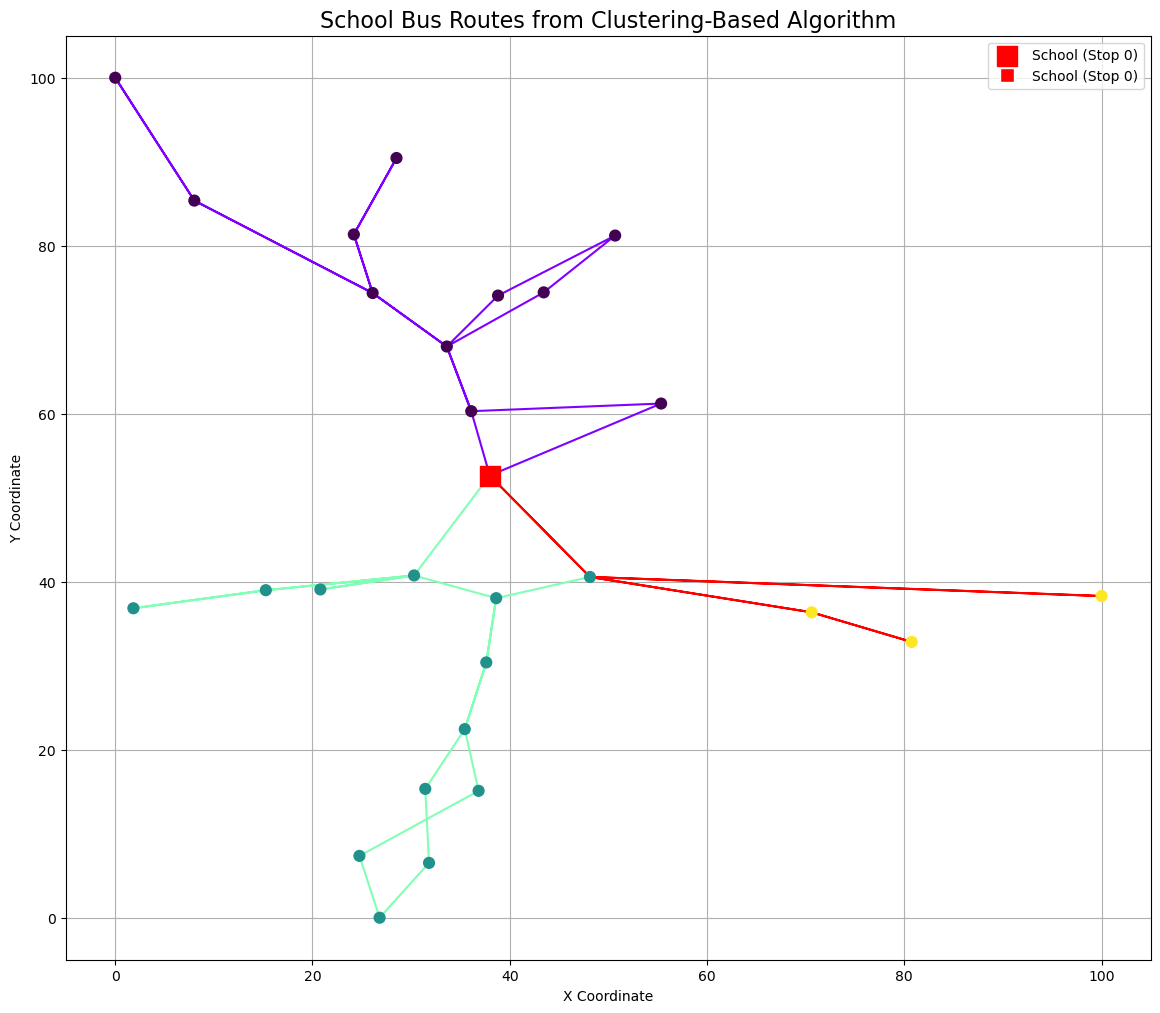

In [11]:
# Visualize Clustering-Based Algorithms

if labels is not None:
    visualize_routes(stops, school, clustering_routes, "Clustering-Based Algorithm", cluster_labels=labels)